# 🌾 Crop Recommendation Model Training

This notebook trains a **Random Forest Classifier** to recommend the best crop based on:
- Soil: Nitrogen (N), Phosphorus (P), Potassium (K), pH
- Climate: Temperature, Humidity, Rainfall

Covers:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Model Training (Random Forest)
5. Evaluation
6. Save Model for Backend

## 📦 Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

✅ All libraries imported successfully!
Pandas: 2.2.2 | NumPy: 1.26.4


## 📂 Step 2: Load Dataset

In [5]:
# Auto-detect dataset location
possible_paths = [
    '../dataset/Crop_recommendation.csv',
    '../backend/Crop_recommendation.csv',
    'Crop_recommendation.csv'
]

dataset_path = None
for path in possible_paths:
    if os.path.exists(path):
        dataset_path = path
        print(f'✅ Dataset found at: {path}')
        break

if dataset_path is None:
    raise FileNotFoundError('❌ Dataset not found! Place Crop_recommendation.csv in the dataset/ folder.')

df = pd.read_csv(dataset_path)
print(f'\n📊 Dataset Shape: {df.shape}')
print(f'📌 Crops: {df["label"].nunique()} unique crops')
df.head(10)

✅ Dataset found at: ../backend/Crop_recommendation.csv

📊 Dataset Shape: (2200, 8)
📌 Crops: 22 unique crops


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [6]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Statistical Summary ===')
print(df.describe().round(2))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

=== Statistical Summary ===
             N        P        K  temperature  humidity       ph  rainfall
count  2200.00  2200.00  2200.00      2200.00   2200.00  2200.00   2200.00
mean     50.55    53.36    48.15        25.62     71.48     6.47    103.46
std      36.92    32.99    50.65         5.06     22.26     0.77     54.96
min       0.00     5.00     5.00         8.83     14.26

In [7]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '✅ No missing values!')

print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'✅ Removed duplicates. New shape: {df.shape}')

=== Missing Values ===
✅ No missing values!

=== Duplicate Rows ===
Duplicates: 0


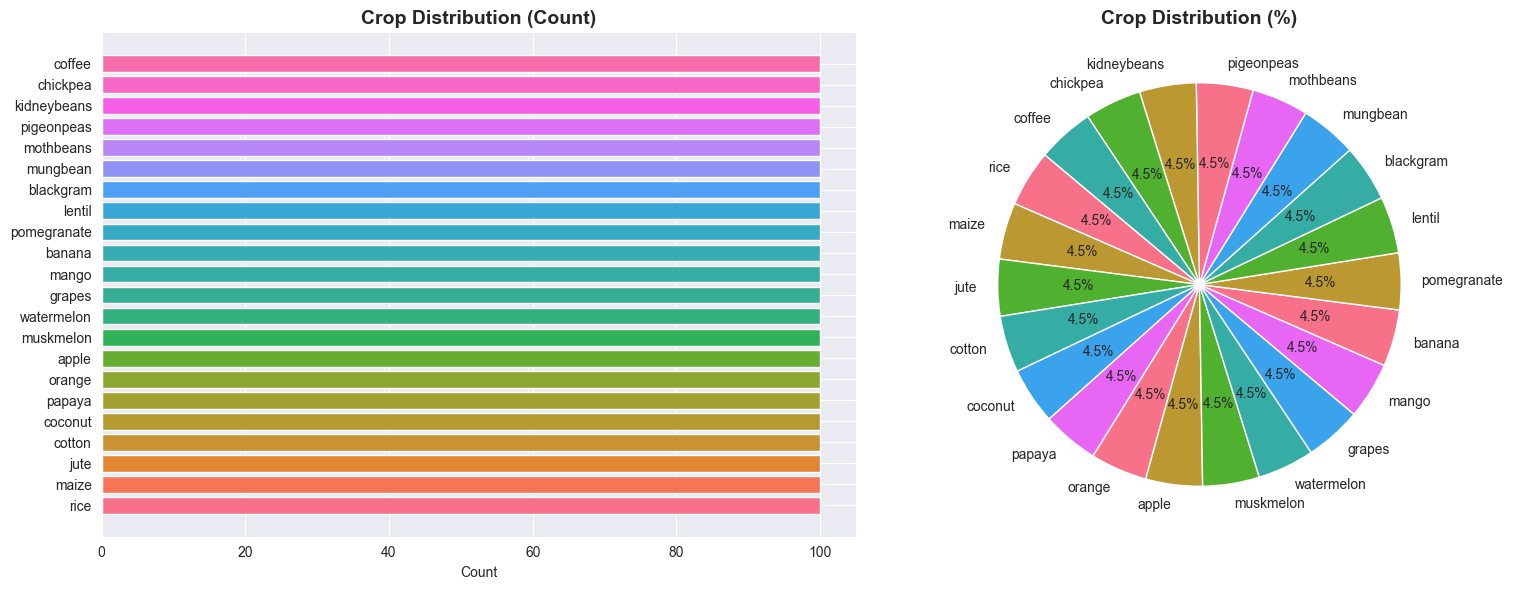

✅ Class distribution is balanced!


In [8]:
# Crop distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

crop_counts = df['label'].value_counts()
axes[0].barh(crop_counts.index, crop_counts.values, color=sns.color_palette('husl', len(crop_counts)))
axes[0].set_title('Crop Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

axes[1].pie(crop_counts.values, labels=crop_counts.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Crop Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/crop_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class distribution is balanced!')

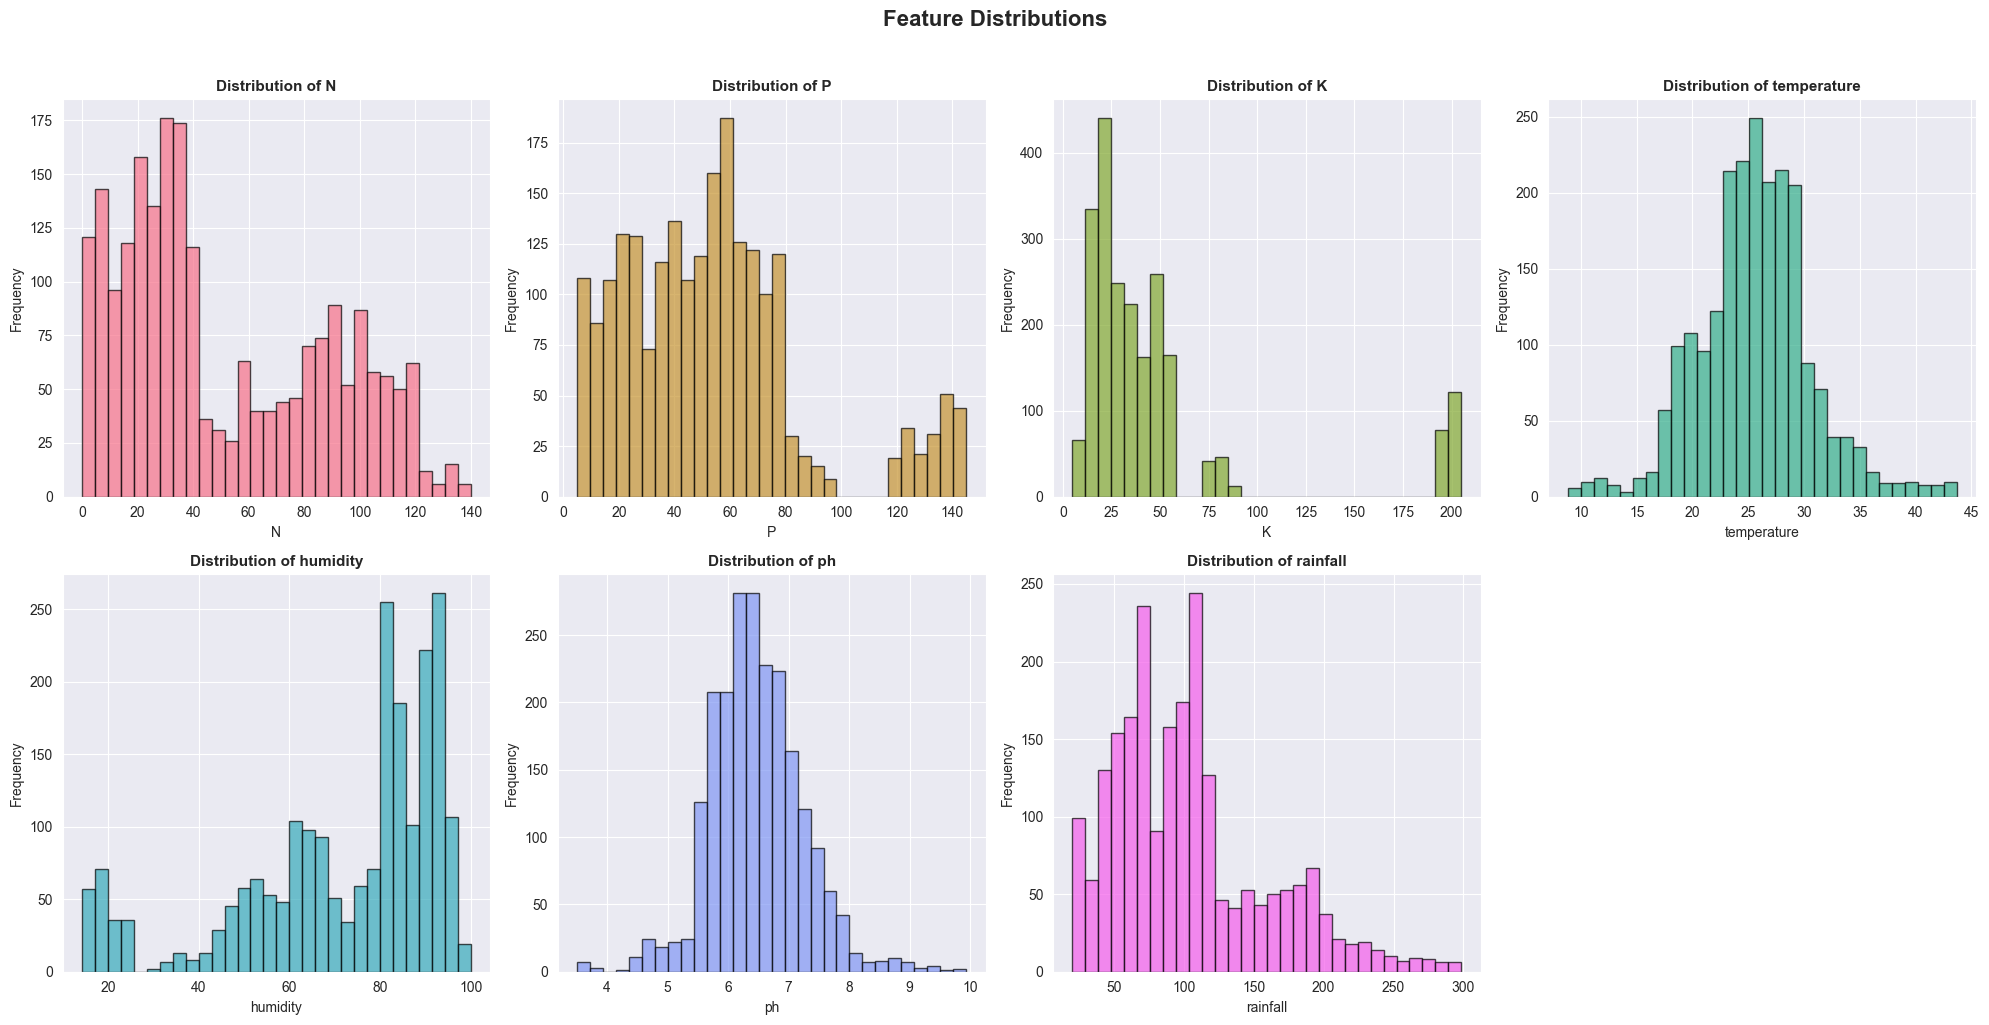

In [9]:
# Feature distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color=sns.color_palette('husl', 7)[i])
    axes[i].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

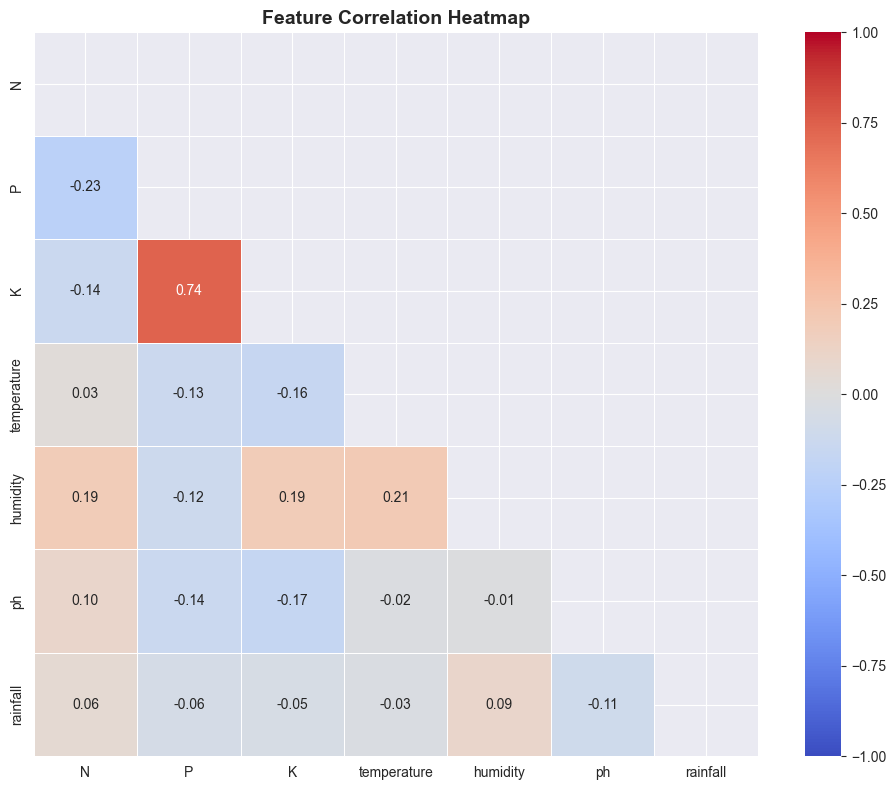

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

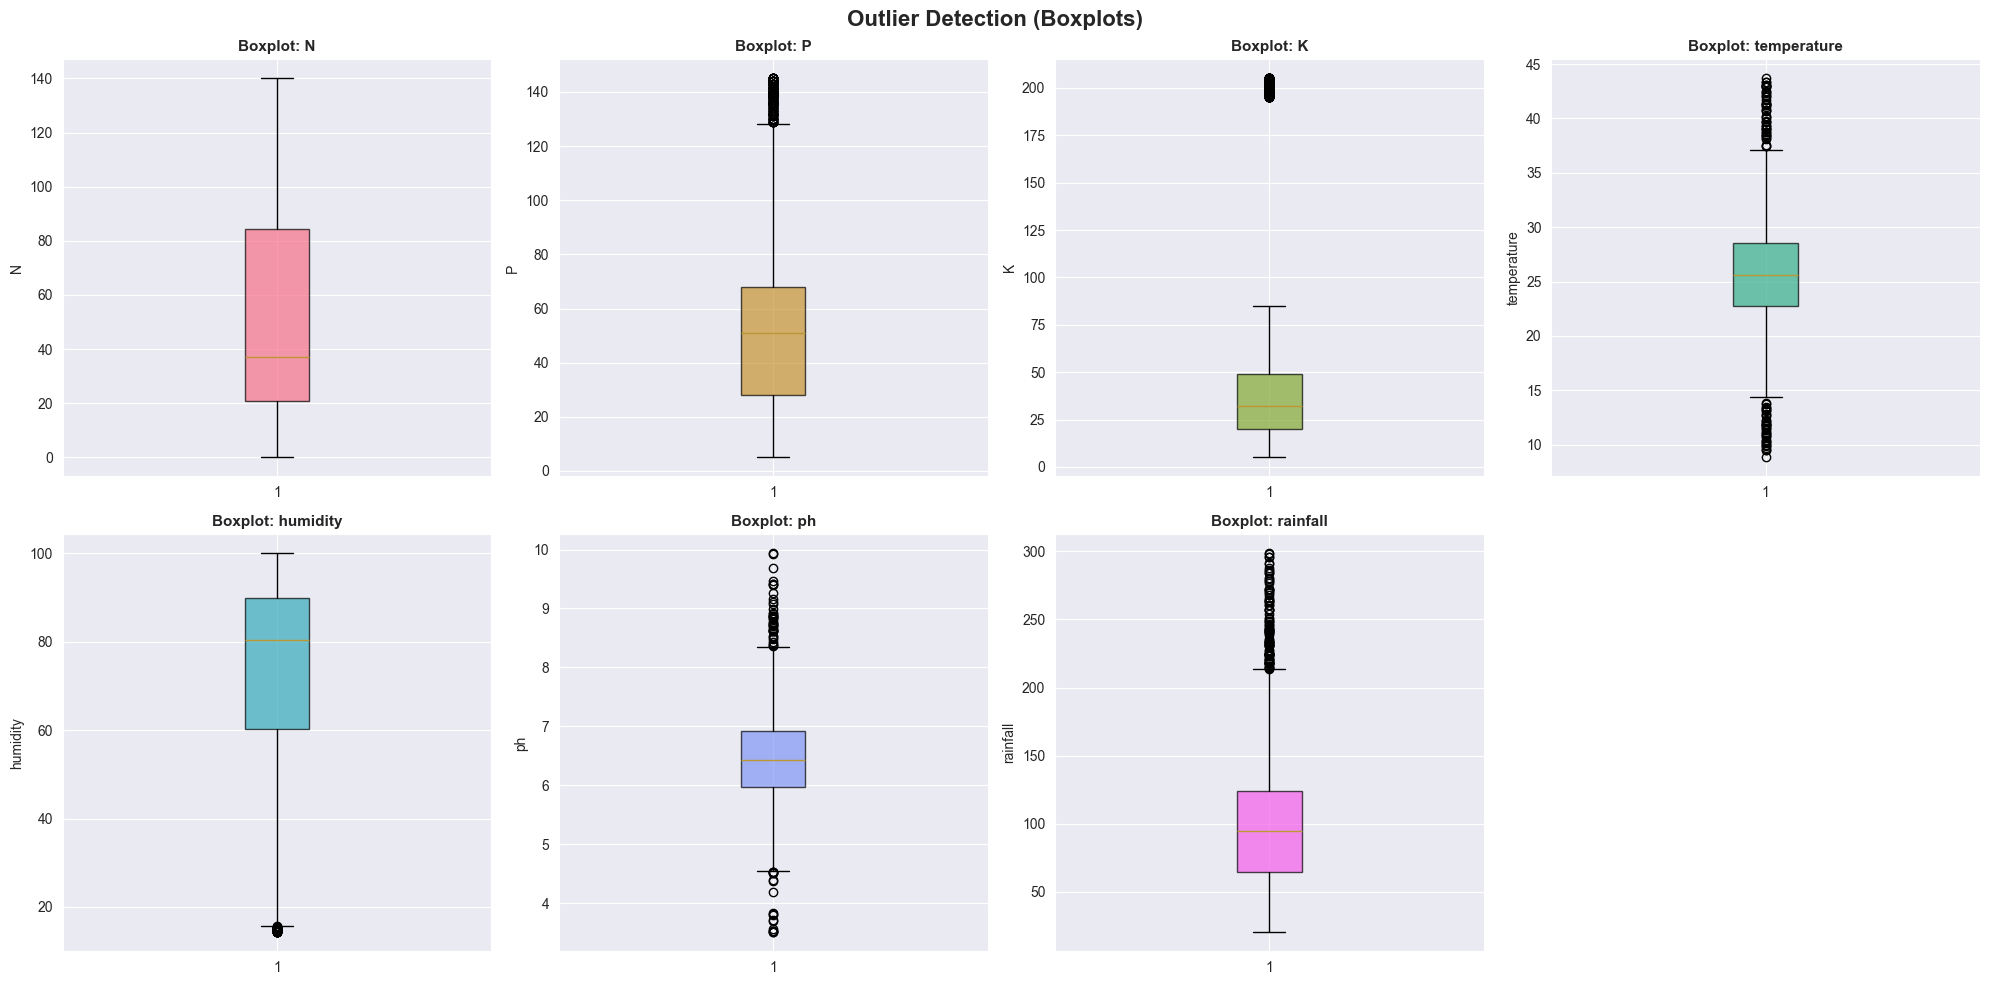

In [11]:
# Boxplot to check outliers
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(df[feature], patch_artist=True,
                    boxprops=dict(facecolor=sns.color_palette('husl', 7)[i], alpha=0.7))
    axes[i].set_title(f'Boxplot: {feature}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(feature)

axes[-1].axis('off')
plt.suptitle('Outlier Detection (Boxplots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ Step 4: Preprocessing

In [12]:
# IQR-based outlier removal for numerical features
original_size = len(df)

for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR   # Using 3x IQR to avoid over-filtering
    upper = Q3 + 3 * IQR
    df = df[(df[feature] >= lower) & (df[feature] <= upper)]

print(f'Before outlier removal: {original_size} rows')
print(f'After outlier removal:  {len(df)} rows')
print(f'Removed: {original_size - len(df)} rows')

Before outlier removal: 2200 rows
After outlier removal:  1998 rows
Removed: 202 rows


In [13]:
# Encode target labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print('=== Label Encoding Mapping ===')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx:2d} → {cls}')

# Save label encoder
os.makedirs('../backend/models', exist_ok=True)
joblib.dump(le, '../backend/models/label_encoder.pkl')
print('\n✅ Label encoder saved.')

=== Label Encoding Mapping ===
   0 → banana
   1 → blackgram
   2 → chickpea
   3 → coconut
   4 → coffee
   5 → cotton
   6 → jute
   7 → kidneybeans
   8 → lentil
   9 → maize
  10 → mango
  11 → mothbeans
  12 → mungbean
  13 → muskmelon
  14 → orange
  15 → papaya
  16 → pigeonpeas
  17 → pomegranate
  18 → rice
  19 → watermelon

✅ Label encoder saved.


In [14]:
# Features and target
X = df[features]
y = df['label']   # Using string labels for easier readability

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Testing set:   {X_test.shape[0]} samples')
print(f'Features:      {list(X.columns)}')

Training set:  1598 samples
Testing set:   400 samples
Features:      ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [15]:
# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, '../backend/models/scaler.pkl')
print('✅ StandardScaler fitted and saved.')
print(f'\nMean per feature:\n{pd.Series(scaler.mean_, index=features).round(3)}')

✅ StandardScaler fitted and saved.

Mean per feature:
N               53.140
P               45.551
K               32.977
temperature     25.866
humidity        69.935
ph               6.512
rainfall       104.420
dtype: float64


## 🤖 Step 5: Model Training

In [16]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print(f'✅ Model Trained!')
print(f'   Accuracy:    {acc*100:.2f}%')
print(f'   F1 Score:    {f1:.4f}')

✅ Model Trained!
   Accuracy:    100.00%
   F1 Score:    1.0000


In [17]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'Cross-Validation Scores: {cv_scores.round(4)}')
print(f'Mean CV Accuracy:        {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')

Cross-Validation Scores: [0.9975 0.99   0.995  0.995  0.99  ]
Mean CV Accuracy:        99.35% ± 0.30%


## 📊 Step 6: Model Evaluation

In [18]:
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=rf_model.classes_))

=== Classification Report ===
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
        jute       1.00      1.00      1.00        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00      1.00      1.00        20
  pigeonpeas       1.00      1.00      1.00        

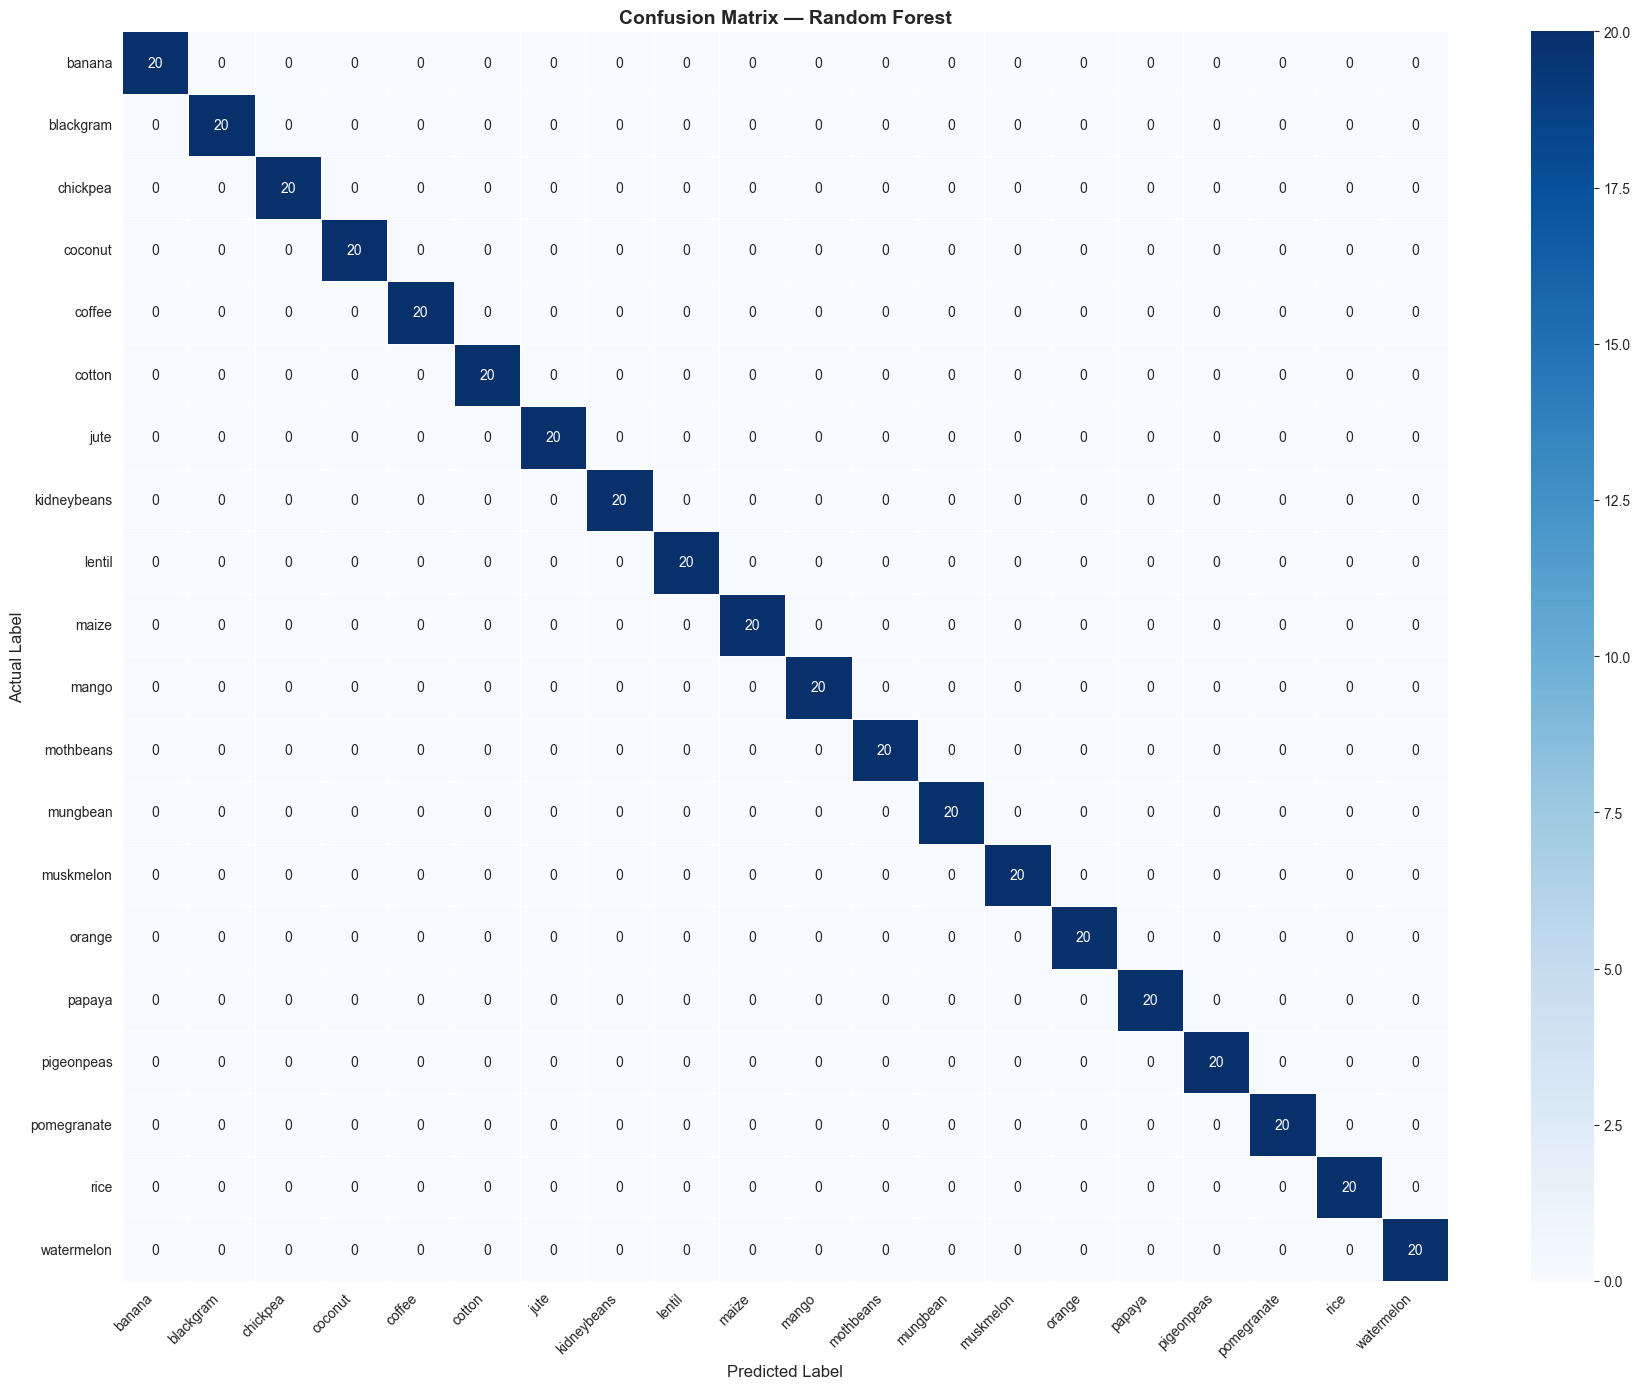

In [19]:
# Confusion Matrix
plt.figure(figsize=(18, 14))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_,
    cmap='Blues', linewidths=0.5
)
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

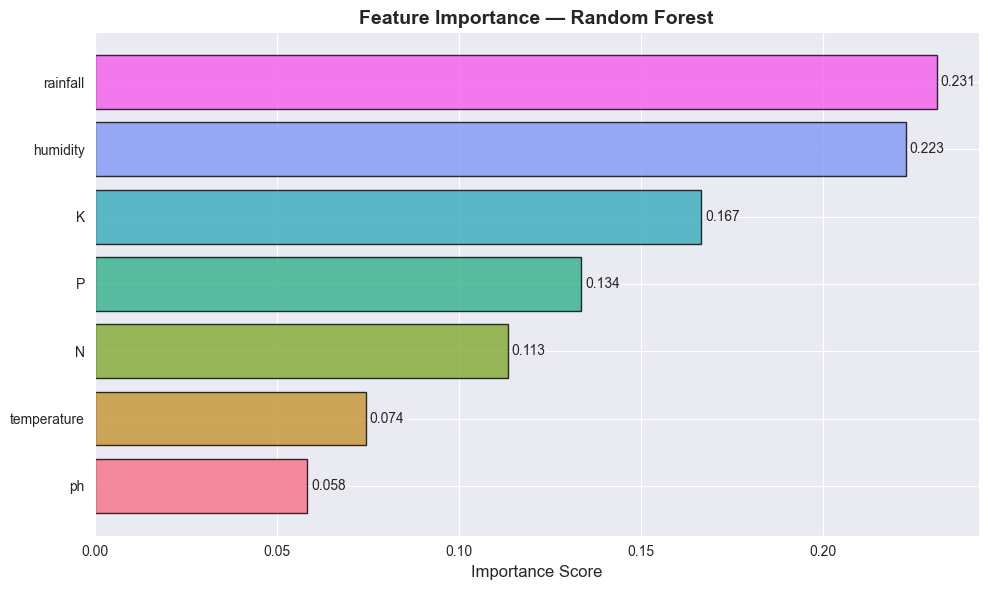

In [20]:
# Feature Importance
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('husl', len(features))
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='black', alpha=0.8)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
for i, (val, name) in enumerate(zip(feat_df['Importance'], feat_df['Feature'])):
    plt.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 Step 7: Save Model

In [21]:
os.makedirs('../backend/models', exist_ok=True)

# Save model
joblib.dump(rf_model, '../backend/models/crop_model.pkl')
# Save feature names
joblib.dump(features, '../backend/models/features.pkl')

print('✅ crop_model.pkl saved → backend/models/')
print('✅ features.pkl    saved → backend/models/')
print('✅ label_encoder.pkl saved → backend/models/')
print('✅ scaler.pkl      saved → backend/models/')

print(f'\nModel Accuracy: {acc*100:.2f}%')
print(f'Total crops supported: {len(rf_model.classes_)}')
print(f'Crops: {list(rf_model.classes_)}')

✅ crop_model.pkl saved → backend/models/
✅ features.pkl    saved → backend/models/
✅ label_encoder.pkl saved → backend/models/
✅ scaler.pkl      saved → backend/models/

Model Accuracy: 100.00%
Total crops supported: 20
Crops: ['banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


## 🌾 Step 8: Test a Sample Prediction

In [22]:
# Test samples (real-world-like values)
test_samples = [
    {'N': 90, 'P': 42, 'K': 43, 'temperature': 20.8, 'humidity': 82.0, 'ph': 6.5, 'rainfall': 202.9},
    {'N': 30, 'P': 40, 'K': 20, 'temperature': 26.0, 'humidity': 60.0, 'ph': 7.2, 'rainfall': 80.0},
    {'N': 75, 'P': 50, 'K': 35, 'temperature': 24.0, 'humidity': 75.0, 'ph': 6.0, 'rainfall': 150.0},
]

print('=== Sample Predictions ===\n')
for i, sample in enumerate(test_samples, 1):
    sample_df = pd.DataFrame([sample])
    pred = rf_model.predict(sample_df)[0]
    proba = max(rf_model.predict_proba(sample_df)[0])
    print(f'Sample {i}: N={sample["N"]}, P={sample["P"]}, K={sample["K"]}, pH={sample["ph"]}')
    print(f'  🌾 Recommended: {pred.upper()} | Confidence: {proba*100:.1f}%\n')

=== Sample Predictions ===

Sample 1: N=90, P=42, K=43, pH=6.5
  🌾 Recommended: RICE | Confidence: 100.0%

Sample 2: N=30, P=40, K=20, pH=7.2
  🌾 Recommended: MOTHBEANS | Confidence: 52.0%

Sample 3: N=75, P=50, K=35, pH=6.0
  🌾 Recommended: JUTE | Confidence: 67.0%

